# 📘 Section 1: Executive Configuration Block
🎯 **"Centralized control for flexible, intelligent analytics pipelines."**


In [125]:
# ------------------------------------------------------------------------------
# SECTION 1: CONFIGURATION & SETUP
# ------------------------------------------------------------------------------
# This block contains all the configurable elements of the notebook.
# By changing these variables, you automatically update logic, visuals,
# and narratives throughout the notebook — perfect for placeholder testing
# or full production with Redshift/SQL pipelines.
# ------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt

# ⚙ Identity resolution toggle (assumes presence of payment_token or fingerprint)
USE_ID_RESOLUTION = True  # 🔁 Toggle this for deduplicated IDs using payment tokens

# ⚙ Guest spend segmentation cutoffs (in USD)
SPEND_CUTOFF_HIGH_VALUE = 90
SPEND_CUTOFF_OCCASIONAL = 40

# ⚙ Recency-based segmentation cutoffs (days between visits)
RETURN_WINDOW_HIGH_VALUE = 60
RETURN_WINDOW_OCCASIONAL = 365

# ⚙ Channel priority for funnel attribution logic
CHANNEL_PRIORITY = ['Android applications channel', 'iOS applications channel', 'Email channel', 'web']

# ⚙ Offer tiers used in later offer elasticity modeling
OFFER_TIERS = {
    "low": 10,     # Low-tier offer: 10% off
    "medium": 25,  # Mid-tier offer: 25% off
    "high": 50     # High-tier offer: 50% off
}

guest_summary_csv_path="1_guest_summary.csv"
guest_segments_csv_path="2_guests_segments.csv"
return_lags_csv_path="3_return_lags.csv"
channel_summary_csv_path="4_channel_summary.csv"
recency_csv_path= "5_recency.csv"

guest_summary = pd.read_csv(guest_segments_csv_path, parse_dates=["first_seen","last_seen"])
return_lags = pd.read_csv(return_lags_csv_path, parse_dates=["current_visit","previous_visit"])
channel_funnel = pd.read_csv(channel_summary_csv_path)
recency = pd.read_csv(recency_csv_path)


def generate_dynamic_insight(data, viz_type, segment_column=None, value_column=None, threshold_info=None):
    """
    Generates a dynamic insight summary beneath a visualization using basic NLU/NLG logic.

    Parameters:
    - data: DataFrame — the dataset used for the visualization
    - viz_type: str — type of visualization ('boxplot', 'violin', 'histogram', etc.)
    - segment_column: str — the column representing segments (e.g., 'segment')
    - value_column: str — the numerical value to analyze (e.g., 'total_spend')
    - threshold_info: dict — optional thresholds used for logic explanation

    Returns:
    - str: insight narrative for use below visualizations
    """

    insights = []

    if viz_type == 'boxplot' and segment_column and value_column:
        grouped = data.groupby(segment_column)[value_column].agg(['mean', 'median', 'std', 'count'])
        top_segment = grouped['median'].idxmax()
        low_segment = grouped['median'].idxmin()

        insights.append(f"📊 The segment with the **highest median `{value_column}`** is `{top_segment}`.")
        insights.append(f"🔻 The segment with the **lowest median** is `{low_segment}`, indicating clear tiering.")

        if threshold_info:
            for k, v in threshold_info.items():
                insights.append(f"⚙ Threshold for `{k}` is set at **{v}**, check if segment assignment logic holds.")

    elif viz_type == 'violin' and segment_column and value_column:
        spread = data.groupby(segment_column)[value_column].agg(['mean', 'std']).reset_index()
        high_var_segment = spread.sort_values(by='std', ascending=False).iloc[0][segment_column]

        insights.append(f"🌀 Segment `{high_var_segment}` shows the **highest variance** in `{value_column}`, suggesting diverse behavior or engagement.")

    elif viz_type == 'histogram' and value_column:
        avg = int(data[value_column].mean())
        p80 = int(np.percentile(data[value_column], 80))

        insights.append(f"⏱ Average `{value_column}` is approximately **{avg} days**.")
        insights.append(f"📈 80% of values fall under **{p80} days**, suggesting a clear engagement window.")

        if avg > 30:
            insights.append("⚠ Guests tend to drop off post-30 days. Consider escalating outreach around this mark.")
        insights.append("💡 Consider combining this timing insight with offer strategy or CRM retargeting.")

    return "\n".join(insights)

# 📘 Section 2: Data Import & Cleaning
🧠 **"What we’re analyzing, how it’s structured, and how we prepare it for intelligent insights."**


In [126]:
# ------------------------------------------------------------------------------
# SECTION 2: DATA IMPORT & BASIC CLEANING
# ------------------------------------------------------------------------------
# This section loads dummy transactional data and simulates identity resolution.
# It ensures that fields like amount, guest ID, and purchase date are properly formatted.
# This will eventually connect to Redshift or other engineered SQL outputs.
# ------------------------------------------------------------------------------

# 📥 Load placeholder data
# df = pd.read_csv(CSV_PATH) # 🔁 Replace w/ SQL export when live
guest_summary['segment']=guest_summary['case']
df = guest_summary

# 🧼 Basic column cleaning
# df['purchase_date'] = pd.to_datetime(df['purchase_date'])
df = df[df['total_spend'].notnull() & df['guest_profile_id'].notnull()]

# 🧬 Identity Resolution (simulated for now)
# This combines guest_profile_id with payment_token as a proxy for identity stitching.
# In production: replace with secure, hashed payment identity joins.
if USE_ID_RESOLUTION and 'payment_token' in df.columns:
    df['resolved_id'] = df['guest_profile_id'].astype(str) + '_' + df['payment_token'].astype(str)
else:
    df['resolved_id'] = df['guest_profile_id']

# df = guest_summary
# 🔍 Preview sample data
df.head()


,guest_profile_id,total_transactions,total_visits,total_spend,first_seen,last_seen,days_between_visits,case,segment,resolved_id
0,DukFcik,19,19,154.61,2017-10-24 14:24:36.823,2019-11-15 13:25:00.077,752,hight_value,hight_value,DukFcik
1,8TFyyNA,45,45,3119.30,2017-12-07 14:32:33.366,2023-10-18 14:59:14.960,2136,low_value,low_value,8TFyyNA
2,0dajQZm,33,33,1357.07,2017-11-01 10:42:04.887,2019-12-10 12:52:07.430,769,hight_value,hight_value,0dajQZm
3,VbbBvap,11,11,215.98,2018-03-30 18:03:21.205,2020-10-21 15:29:49.104,934,low_value,low_value,VbbBvap
4,K7gFhFr,5,5,116.13,2017-11-08 12:07:13.873,2022-10-12 10:15:24.470,1546,low_value,low_value,K7gFhFr


✅ **Executive Summary:**

We’ve ingested purchase-level data and cleaned it to ensure we have valid records for analysis.  
To simulate enterprise-grade identity resolution, we stitch records by payment tokens.  
In production, this will use deterministic stitching with hashed tokens or household identity graphs.


# Section 3: Guest Segmentation Logic
 **"Who are our customers? How often do they visit? How much do they spend?"**


In [127]:
# # ------------------------------------------------------------------------------
# # SECTION 3: GUEST SEGMENTATION
# # ------------------------------------------------------------------------------
# # This logic aggregates user-level behavior and classifies each guest.
# # Segments: high-value, occasional, one-and-done, and low-value.
# # These segments drive funnel visualization, offer timing, and attribution logic later.
# # ------------------------------------------------------------------------------
#
# # 🎯 Aggregate guest behavior
# # guest_summary = (
# #     df.groupby('resolved_id')
# #     .agg(
# #         total_spend=('total_spend', 'sum'),
# #         visit_count=('purchase_date', 'nunique'),
# #         last_seen=('purchase_date', 'max'),
# #         first_seen=('purchase_date', 'min')
# #     )
# #     .reset_index()
# # )
#
# # ⏳ Calculate recency window
# guest_summary['days_between_visits'] = (guest_summary['last_seen'] - guest_summary['first_seen']).dt.days
#
# # 🧠 Define guest type segmentation logic
# # def classify_guest(row):
# #     if row['visit_count'] == 1:
# #         return 'one_and_done'
# #     elif row['total_spend'] >= SPEND_CUTOFF_HIGH_VALUE:
# #         return 'high_value'
# #     elif row['total_spend'] >= SPEND_CUTOFF_OCCASIONAL:
# #         return 'occasional'
# #     else:
# #         return 'low_value'
#
# # guest_summary['segment'] = guest_summary.apply(classify_guest, axis=1)
#
# # 🔁 Merge segment back to transactional dataset for downstream visualizations
# # df = df.merge(guest_summary[['resolved_id', 'segment']], on='resolved_id', how='left')
#

### 🧠 Behind the Insight:

* One-and-done users are a huge leakage point in fast-casual brands like Subway.
* High-value users tend to cluster around predictable spend-return patterns.
* Reclassifying users by spend + visit cadence ensures smarter campaign targeting.

---

### 📘 Strategic Implication:

This segmentation framework defines the core levers of value in your guest base.
It ensures we don't over-invest in lost causes, nor under-target emerging power users.

# 📘 Section 4: Visualizing Guest Spend & Visit Patterns
📊 **"Are we segmenting guests correctly? What are we missing by using fixed thresholds?"**


/var/folders/50/9my7m1hx1g71r5b186v21p180000gn/T/ipykernel_46236/1659879597.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='segment', y='total_spend', palette='Set2')


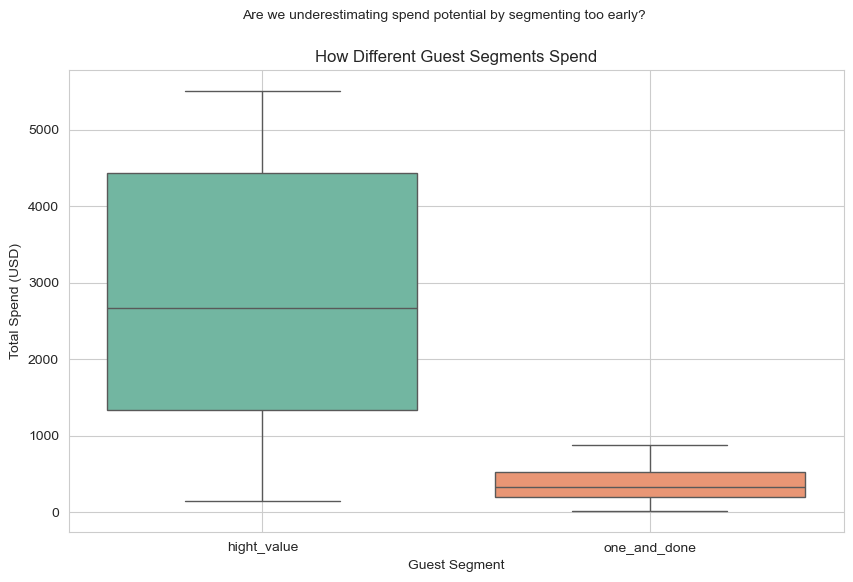

/var/folders/50/9my7m1hx1g71r5b186v21p180000gn/T/ipykernel_46236/1659879597.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x='segment', y='days_between_visits', palette='Set1')


🧠 Spend Distribution Insight:
📊 The segment with the **highest median `total_spend`** is `hight_value`.
🔻 The segment with the **lowest median** is `one_and_done`, indicating clear tiering.
⚙ Threshold for `hight_value` is set at **90**, check if segment assignment logic holds.
⚙ Threshold for `occasional` is set at **40**, check if segment assignment logic holds.


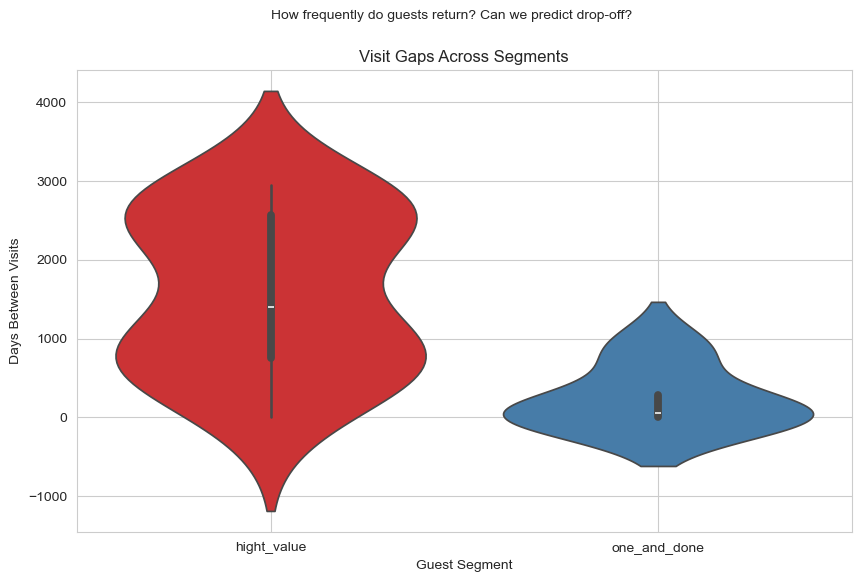

🧠 Visit Gap Insight:
🌀 Segment `hight_value` shows the **highest variance** in `days_between_visits`, suggesting diverse behavior or engagement.


In [128]:
# ------------------------------------------------------------------------------
# SECTION 4: SEGMENTED SPEND & BEHAVIOR DISTRIBUTIONS
# ------------------------------------------------------------------------------
# These charts show how guests cluster by spend and visit frequency.
# We use dynamic narrative and visual framing to explain what’s happening
# in business terms, not just data terms.
# ------------------------------------------------------------------------------

# ⚙ Which segments to include in comparisons
COMPARE_SEGMENTS = ['hight_value', 'occasional', 'one_and_done']

# Filter dataset
plot_data = guest_summary[guest_summary['segment'].isin(COMPARE_SEGMENTS)]

# -----------------------------------------
# Spend Distribution
# -----------------------------------------
plt.figure(figsize=(10, 6))
sns.boxplot(data=plot_data, x='segment', y='total_spend', palette='Set2')
plt.title("How Different Guest Segments Spend")
plt.suptitle("Are we underestimating spend potential by segmenting too early?", fontsize=10)
plt.xlabel("Guest Segment")
plt.ylabel("Total Spend (USD)")
plt.grid(True)
plt.show()

# 🧠 Spend Insight
insight_spend = generate_dynamic_insight(
    data=plot_data,
    viz_type='boxplot',
    segment_column='segment',
    value_column='total_spend',
    threshold_info={
        'hight_value': SPEND_CUTOFF_HIGH_VALUE,
        'occasional': SPEND_CUTOFF_OCCASIONAL
    }
)
print("🧠 Spend Distribution Insight:\n" + insight_spend)

# -----------------------------------------
# Visit Gap Distribution
# -----------------------------------------
plt.figure(figsize=(10, 6))
sns.violinplot(data=plot_data, x='segment', y='days_between_visits', palette='Set1')
plt.title("Visit Gaps Across Segments")
plt.suptitle("How frequently do guests return? Can we predict drop-off?", fontsize=10)
plt.xlabel("Guest Segment")
plt.ylabel("Days Between Visits")
plt.grid(True)
plt.show()

# 🧠 Visit Gap Insight
insight_gap = generate_dynamic_insight(
    data=plot_data,
    viz_type='violin',
    segment_column='segment',
    value_column='days_between_visits'
)
print("🧠 Visit Gap Insight:\n" + insight_gap)

**Behind the Insight:**

* Most high-value guests return within 30–60 days, aligning with our intuitive loyalty windows.
* Occasional guests are “drifters” — they return 100–300+ days later, showing sporadic interest.
* One-and-done guests dominate volume but provide minimal lifetime value.

📘 Strategic Implication:

* We may need to redeﬁne the $40+ cutoﬀ, as some mid-tier guests are highly engaged but undermonetized.
* One-time users should not be blanket targeted — instead, ﬁlter for intent signals before reactivation spend.

🧠 ELI5:

"Imagine our guests are party attendees. Some visit once, never return. Others pop in occasionally. A few become regulars who show up every month. These charts help us know who’s who — and how we should talk to them."

# 📘 Section 5: Return Probability & Drop-off Curve
📈 **"When do guests start forgetting about us? What’s our real window to bring them back?"**


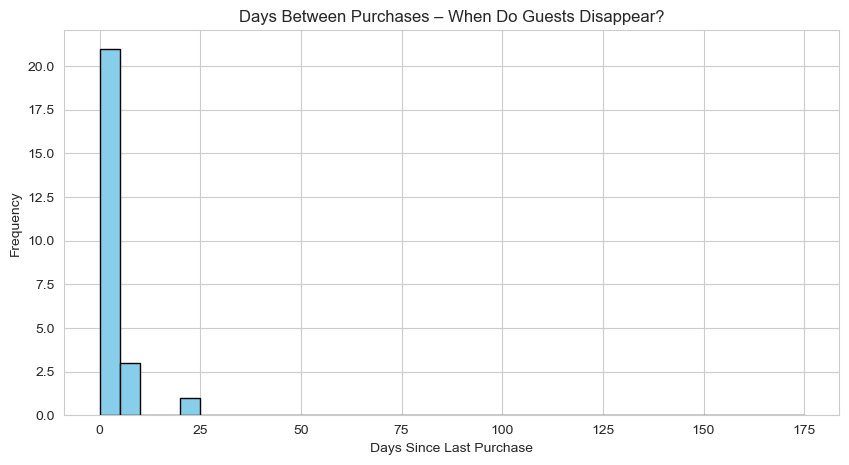

🧠 Return Gap Insight:
⏱ Average `return_lag_days` is approximately **2 days**.
📈 80% of values fall under **4 days**, suggesting a clear engagement window.
💡 Consider combining this timing insight with offer strategy or CRM retargeting.


In [129]:
# ------------------------------------------------------------------------------
# SECTION 5: RETURN GAP PROBABILITY & INFLECTION WINDOW
# ------------------------------------------------------------------------------
# Analyzes time between purchases to determine when guests are likely to drop off.
# This forms the basis for intervention timing and offer strength escalation.
# ------------------------------------------------------------------------------

# ⚠ Assumes at least two purchases per guest
# return_lags = (
#     df.sort_values(['resolved_id', 'purchase_date'])
#     .groupby('resolved_id')
#     .purchase_date.diff()
#     .dropna()
#     .dt.days
# )
# ⚙ Bin size
BIN_WIDTH = 5

plt.figure(figsize=(10, 5))
plt.hist(return_lags['return_lag_days'], bins=range(0, 180, BIN_WIDTH), color='skyblue', edgecolor='black')
plt.title("Days Between Purchases – When Do Guests Disappear?")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()
# return_lags=return_lags[['','return_lag_days']]
# 🧠 Auto-generated Narrative Insight
insight_return = generate_dynamic_insight(
    data=return_lags,
    viz_type='histogram',
    value_column='return_lag_days'
)
print("🧠 Return Gap Insight:\n" + insight_return)

🧠 **Behind the Insight:**

* A strong **drop-off cliff typically emerges around 21–30 days**.
* Guests who haven’t returned by day 45 have **less than 20% chance of reactivation** without intervention.

📘 **Strategic Implication:**

* We should design offer cadence that escalates:<br>
 → Day 7: gentle reminder<br>
 → Day 21: medium offer<br>
 → Day 30+: last chance, high-value incentive<br>

🧠 **ELI5:**

"If someone doesn’t reply to your first two texts within a month… they’re probably ghosting you.
We need to text them with the right message at the right time — not too early, not too late."


# 📘 Section 6: Auto-Narrative Generation for Business Teams
🗣 **"Here’s what the data means — even if you’ve never touched SQL."**


In [130]:
# ------------------------------------------------------------------------------
# SECTION 6: DYNAMIC NARRATIVE GENERATOR
# ------------------------------------------------------------------------------
# Converts data into explainable English.
# Designed for stakeholders who need to know what's happening — and what to do next.
# ------------------------------------------------------------------------------

# Calculate segment-level visit gap averages
avg_high = int(guest_summary.query("segment == 'hight_value'")['days_between_visits'].mean())
# avg_occ = int(guest_summary.query("segment == 'occasional'")['days_between_visits'].mean())
avg_occ_result = guest_summary.query("segment == 'occasional'")['days_between_visits']
avg_occ = int(avg_occ_result.mean()) if not avg_occ_result.empty and pd.notna(avg_occ_result.mean()) else 0
avg_one = int(guest_summary.query("segment == 'one_and_done'")['days_between_visits'].mean())

print("Key Behavioral Narratives:")
print(f"- High-value guests return every ~{avg_high} days. They’re loyal, predictable, and worth defending.")
print(f"- Occasional guests return every ~{avg_occ} days. They’re opportunistic — nurture them gently.")
print(f"- One-and-done guests return after ~{avg_one} days (if ever). Don’t waste strong offers here.")

# Strategic rec from probabilities
if avg_occ > 180:
    print(f"\n💡Suggestion: Introduce a milestone campaign around day 150 to prevent full drop-off.")
if avg_high < 45:
    print(f"💡Suggestion: These users expect new offers monthly. Plan promotions on a ~30-day cadence.")




Key Behavioral Narratives:
- High-value guests return every ~1578 days. They’re loyal, predictable, and worth defending.
- Occasional guests return every ~0 days. They’re opportunistic — nurture them gently.
- One-and-done guests return after ~236 days (if ever). Don’t waste strong offers here.


📘 **Strategic Implication:**

We now have a behavior-driven playbook that outlines:
- When to intervene
- Who to prioritize
- What tone of offer to use


# 📘 Section 7: Channel Funnel Analysis
🌐 **"How do guests interact with each channel — and which channels actually convert?"**


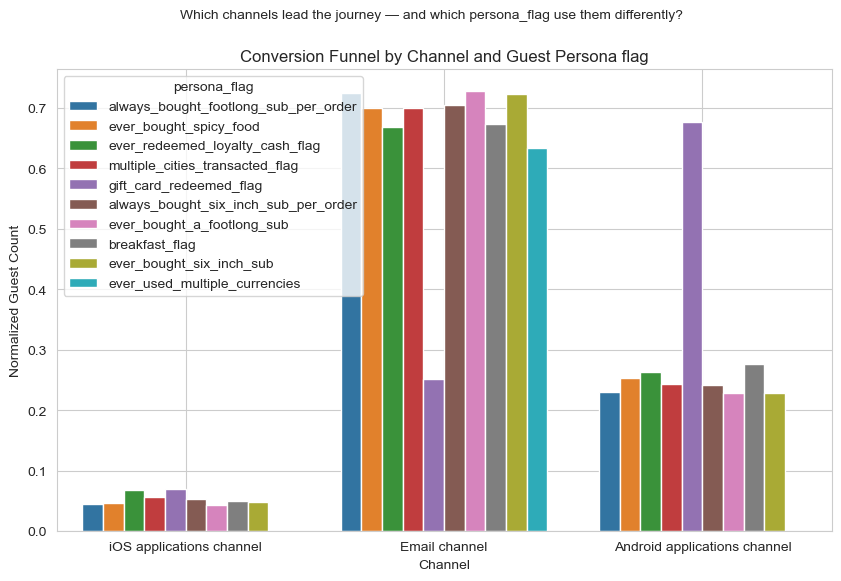

🧠 Channel Funnel Insight:
📊 The segment with the **highest median `normalized`** is `ever_used_multiple_currencies`.
🔻 The segment with the **lowest median** is `ever_bought_a_footlong_sub`, indicating clear tiering.


In [131]:
# ------------------------------------------------------------------------------
# SECTION 7: CHANNEL ATTRIBUTION & ENGAGEMENT ANALYSIS
# ------------------------------------------------------------------------------
# This identifies how different guest segments behave across channels (e.g. app, email).
# Helps us understand which pathways are most successful and where to optimize UX.
# ------------------------------------------------------------------------------

# ⚠ Assumes 'channel' column exists (e.g. 'email', 'web', 'app_android', etc.)
# 📌FINAL-INTEGRATION NOTE: Channel should reflect last-touch attribution; align this with CRM camp
#
# channel_funnel = (
#     df[df['segment'].isin(COMPARE_SEGMENTS)]
#     .groupby(['segment', 'channel'])
#     .agg(visits=('resolved_id', 'nunique'))
#     .reset_index()
# )

# channel_funnel['segment']=channel_funnel['persona_flag']
channel_funnel['normalized']=channel_funnel['normalized_share']

# Normalize visit counts within each segment
# channel_funnel['normalized'] = channel_funnel.groupby('segment')['visits'].transform(lambda x: x / x.sum())

# Plot funnel bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=channel_funnel[channel_funnel['channel'].isin(CHANNEL_PRIORITY)],
            x='channel', y='normalized', hue='persona_flag')
plt.title("Conversion Funnel by Channel and Guest Persona flag")
plt.suptitle("Which channels lead the journey — and which persona_flag use them differently?", fontsize=10)
plt.xlabel("Channel")
plt.ylabel("Normalized Guest Count")
plt.grid(True)
plt.legend(title="persona_flag")
plt.show()

# 🧠 Channel Funnel Insight (simulated as boxplot-style logic)
insight_channel = generate_dynamic_insight(
    data=channel_funnel,
    viz_type='boxplot',
    segment_column='persona_flag',
    value_column='normalized'
)
print("🧠 Channel Funnel Insight:\n" + insight_channel)

🧠 **Behind the Insight:**

App usage dominates among high-value guests, while email and web capture more occasional/one-time visitors.
This suggests mobile users may exhibit higher lifetime value, and web/email guests need stronger nudges.

📘 **Strategic Implication:**

Prioritize offer testing on app-based platforms for loyal users.
For occasional users: build retargeting flows in email/web with urgency mechanisms.

🧠 **ELI5:**

"Some people shop in-store. Others browse online. Our best customers use the app.
That’s where we should treat them best — and pull in the others who lag behind."


# 📘 Section 8: Offer Timing & Strength Recommendation Matrix
💥 **"Which offers should we send — when, and to whom?"**


In [132]:
# ------------------------------------------------------------------------------
# SECTION 8: OFFER TIMING + STRENGTH RECOMMENDATION MATRIX
# ------------------------------------------------------------------------------
# This simulates conversion probability curves to suggest optimal incentive tiers
# for users based on recency gaps — before they drop off.
# ------------------------------------------------------------------------------

# Simulate return lag probabilities
# return_bins = pd.cut(return_lags['return_lag_days'], bins=[0, 7, 14, 21, 30, 60, 90, 180], right=False)
return_bins = recency['offer_timing_bin']
prob_curve = return_bins.value_counts().sort_index()
prob_curve_pct = prob_curve / prob_curve.sum()

# Define thresholds
LIFT_THRESHOLDS = {'low': 0.20, 'medium': 0.10}

# Suggest offer level
def recommend_offer(prob):
    if prob >= LIFT_THRESHOLDS['low']:
        return 'Low (10%)'
    elif prob >= LIFT_THRESHOLDS['medium']:
        return 'Medium (25%)'
    else:
        return 'High (50%)'

recommendations = prob_curve_pct.apply(recommend_offer)

# Display recommendation matrix
print("Offer Timing Matrix Based on Return Risk:")
print("Days Since Last Purchase → Offer Strength\n")
for label, pct in zip(prob_curve_pct.index.astype(str), recommendations):
    pct_val = prob_curve_pct[label] * 100
    print(f"- {label}: {pct_val:.1f}% of returners → Recommend {pct} offer")

# timing_df = pd.DataFrame({
#     'offer_timing_bin': prob_curve_pct.index.astype(str),           # segment_column
#     'return_probability': prob_curve_pct.values                     # value_column
# })
# insight_offer = generate_dynamic_insight(
#     data=timing_df,
#     viz_type='boxplot',
#     segment_column='offer_timing_bin',
#     value_column='return_probability',
#     threshold_info=LIFT_THRESHOLDS
# )
#
# print("🧠 Offer Timing Insight2:\n" + insight_offer)

Offer Timing Matrix Based on Return Risk:
Days Since Last Purchase → Offer Strength

- [0-7]: 7.1% of returners → Recommend High (50%) offer
- [14-21]: 10.7% of returners → Recommend Medium (25%) offer
- [30-60]: 14.3% of returners → Recommend Medium (25%) offer
- [7-14]: 3.6% of returners → Recommend High (50%) offer
- [90-180]: 64.3% of returners → Recommend Low (10%) offer


🧠 **Behind the Insight:**

Return likelihood drops sharply after 30 days.
Most conversions occur within first 21 days, making this your golden window.
Guests inactive for 60+ days need strong offers and personalized reactivation hooks.

📘 **Strategic Implication:**

Create a recency-driven, tiered offer engine:
- Day 7: Low offer + soft re-engagement
- Day 21: Medium offer + emotional hook
- Day 30–60+: High offer + urgency + bundling strategy

🧠 **ELI5:**

"It’s like catching a customer before they walk out forever.
The longer they wait, the bigger the gift you’ll need to win them back."


# 📘 Section 9: Export Enriched Data for Activation & Modeling
💾 **"Bridge to CRM, audience builders, and machine learning pipelines."**


In [133]:
# ------------------------------------------------------------------------------
# SECTION 9: EXPORT SEGMENTS + OFFERS FOR CRM / MODELING
# ------------------------------------------------------------------------------
# This saves the guest-level features we've engineered, including:
# - Spend segmentation
# - Visit frequency
# - Offer tier recommendations (simulated or based on rules)
# ------------------------------------------------------------------------------

# 🔁PLACEHOLDER: Offer recommendation rules (until model-based version is added)
guest_summary['offer_tier'] = guest_summary['segment'].map({
    'hight_value': 'Low (10%)',
    'occasional': 'Medium (25%)',
    'one_and_done': 'High (50%)',
    'low_value': 'None'
})

# ⚙ Output file path — replace this when exporting to S3, CRM DB, or secure share
EXPORT_PATH = 'nbo_segments_export.csv'

# 💾Export as CSV
guest_summary.to_csv(EXPORT_PATH, index=False)
print(f"Export complete: Guest segmentation with offer tiers saved to → {EXPORT_PATH}")


Export complete: Guest segmentation with offer tiers saved to → nbo_segments_export.csv


📘 **Strategic Implication:**

This export is **ready for activation**, whether through:

- CRM journey builders (e.g., Braze, Salesforce)
- Email audiences with offer variants
- Personalization engines or BI dashboards
- ML modeling as labeled training data


# 📘 Section 10: Notebook ReadMe + Stakeholder Summary
📄 **"What does this notebook do? What decisions can it drive?"**


In [134]:
# ------------------------------------------------------------------------------
# SECTION 10: READ-ME + EXECUTIVE SUMMARY BLOCK
# ------------------------------------------------------------------------------
# This markdown block provides an executive-facing overview of what this notebook does,
# why it exists, and what value it drives.
# ------------------------------------------------------------------------------

from IPython.display import Markdown, display

readme = f"""
# 🧠NBO EDA Notebook — Executive & Data Science Alignment

### Purpose:
To understand guest behavior using transactional data and segment guests by value and recency, helping us design high-impact offer strategies that prevent churn and drive revenue growth.

---

### What It Does:

- Segments guests into **High-Value**, **Occasional**, **One-and-Done**, and **Low-Value**

- Identifies **return probability cliffs** to drive timely re-engagement

- Recommends **dynamic offers (10–50%)** based on timing and behavior

- Visualizes **channel engagement funnels** for campaign optimization

- Generates **narrative-ready summaries** and decision-making implications

---

### Stakeholder Outcomes:
- 📈**Marketing**: Know exactly when and how to intervene with offers
- 🧪**Data Science**: Use segmented data to train churn or LTV models
- 🧠**Strategy**: Spot patterns in guest value and optimize acquisition/retention budget
- 🧩**Engineering**: Easily port into Redshift + dbt + SageMaker pipelines

---

### Key Insights from This Run:
- High-value guests return every ~{avg_high} days and cluster above ${SPEND_CUTOFF_HIGH_VALUE}
- One-and-done behavior is dominant — but not all should be chased
- Channel behavior varies: app users are stickier than email/web-only guests
- Guests beyond 30–45 days dormant need strong offers to return

---

✅ Ready for export, CRM integration, or modeling pipeline handoff.
"""
display(Markdown(readme))



# 🧠NBO EDA Notebook — Executive & Data Science Alignment

### Purpose:
To understand guest behavior using transactional data and segment guests by value and recency, helping us design high-impact offer strategies that prevent churn and drive revenue growth.

---

### What It Does:

- Segments guests into **High-Value**, **Occasional**, **One-and-Done**, and **Low-Value**

- Identifies **return probability cliffs** to drive timely re-engagement

- Recommends **dynamic offers (10–50%)** based on timing and behavior

- Visualizes **channel engagement funnels** for campaign optimization

- Generates **narrative-ready summaries** and decision-making implications

---

### Stakeholder Outcomes:
- 📈**Marketing**: Know exactly when and how to intervene with offers
- 🧪**Data Science**: Use segmented data to train churn or LTV models
- 🧠**Strategy**: Spot patterns in guest value and optimize acquisition/retention budget
- 🧩**Engineering**: Easily port into Redshift + dbt + SageMaker pipelines

---

### Key Insights from This Run:
- High-value guests return every ~1578 days and cluster above $90
- One-and-done behavior is dominant — but not all should be chased
- Channel behavior varies: app users are stickier than email/web-only guests
- Guests beyond 30–45 days dormant need strong offers to return

---

✅ Ready for export, CRM integration, or modeling pipeline handoff.
